# Day 1 / 60 — System Design Series
## Single Server Setup

> *Designing a system that supports millions of users is a journey of continuous refinement.*
> *Every large-scale system starts here.*

### What we cover today
1. Architecture diagram — what a single-server system looks like
2. Step-by-step request flow (DNS -> Server -> DB -> Response)
3. Bottleneck identification — CPU, DB, or Network?
4. Scaling triggers — when does this setup break?
5. Key takeaways before we add the next component

---


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import matplotlib.patheffects as pe
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})
print("Ready.")


Ready.


## 1 — Single Server Architecture Diagram

Everything on one box: web server, application logic, and database.


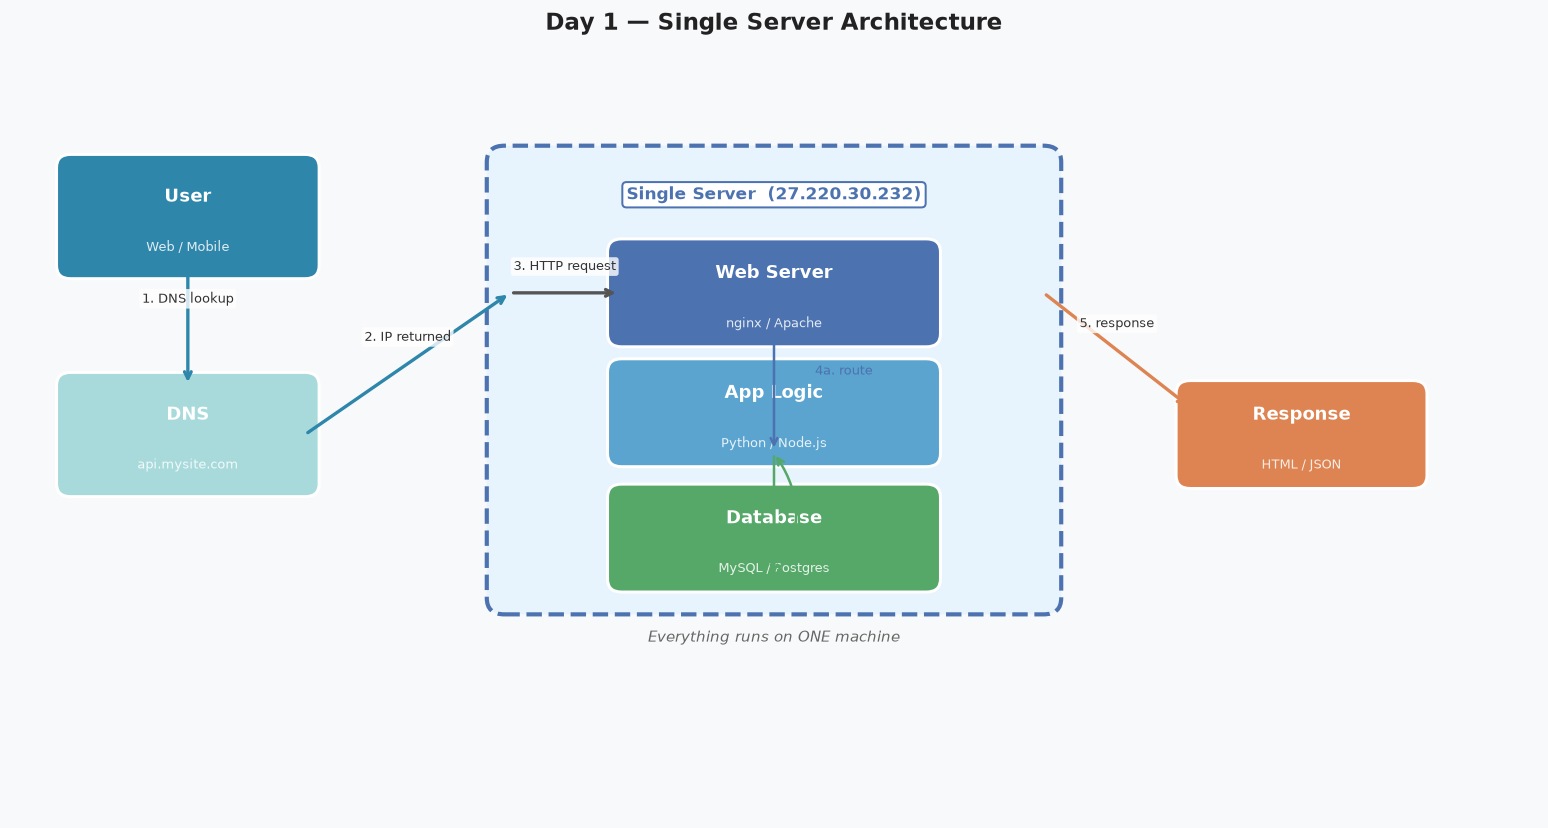

Architecture diagram saved.


In [2]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13); ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

def box(ax, x, y, w, h, label, sublabel='', color='#4C72B0', textcolor='white', fontsize=11):
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle='round,pad=0.12', lw=1.8,
                          facecolor=color, edgecolor='white')
    ax.add_patch(rect)
    ax.text(x, y + (0.18 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color=textcolor)
    if sublabel:
        ax.text(x, y - 0.28, sublabel,
                ha='center', va='center', fontsize=8,
                color=textcolor, alpha=0.85)

def arrow(ax, x1, y1, x2, y2, label='', color='#555', lw=2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=lw, connectionstyle='arc3,rad=0'))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my + 0.18, label, ha='center', va='bottom',
                fontsize=8, color='#333',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, lw=0))

# ── Nodes ─────────────────────────────────────────────────────────────────────
box(ax, 1.5, 5.5, 2.0, 0.9, 'User', 'Web / Mobile', '#2E86AB')
box(ax, 1.5, 3.5, 2.0, 0.9, 'DNS', 'api.mysite.com', '#A8DADC')

# Single server box — larger, highlighted
server_box = FancyBboxPatch((4.2, 2.0), 4.6, 4.0,
                             boxstyle='round,pad=0.15', lw=2.5,
                             facecolor='#E8F4FD', edgecolor='#4C72B0', linestyle='--')
ax.add_patch(server_box)
ax.text(6.5, 5.7, 'Single Server  (27.220.30.232)', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#4C72B0',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#4C72B0', lw=1.2))

box(ax, 6.5, 4.8, 2.6, 0.75, 'Web Server', 'nginx / Apache', '#4C72B0')
box(ax, 6.5, 3.7, 2.6, 0.75, 'App Logic', 'Python / Node.js', '#5BA4CF')
box(ax, 6.5, 2.55, 2.6, 0.75, 'Database', 'MySQL / Postgres', '#55A868')

box(ax, 11.0, 3.5, 1.9, 0.75, 'Response', 'HTML / JSON', '#DD8452')

# ── Arrows ────────────────────────────────────────────────────────────────────
arrow(ax, 1.5, 5.05, 1.5, 3.95, '1. DNS lookup', '#2E86AB')
arrow(ax, 2.5, 3.5, 4.25, 4.8, '2. IP returned', '#2E86AB')
arrow(ax, 4.25, 4.8, 5.18, 4.8, '3. HTTP request')
# internal downward
ax.annotate('', xy=(6.5, 3.35), xytext=(6.5, 4.43),
            arrowprops=dict(arrowstyle='->', color='#4C72B0', lw=1.5))
ax.text(6.85, 4.05, '4a. route', fontsize=8, color='#4C72B0')
ax.annotate('', xy=(6.5, 2.19), xytext=(6.5, 3.33),
            arrowprops=dict(arrowstyle='->', color='#55A868', lw=1.5))
ax.text(6.85, 2.9, '4b. query', fontsize=8, color='#55A868')
ax.annotate('', xy=(6.5, 3.33), xytext=(6.5, 2.19),
            arrowprops=dict(arrowstyle='->', color='#55A868', lw=1.5,
                           connectionstyle='arc3,rad=0.35'))
ax.text(7.55, 2.8, 'result', fontsize=8, color='#55A868')
arrow(ax, 8.8, 4.8, 10.05, 3.75, '5. response', '#DD8452')

# ── Labels ────────────────────────────────────────────────────────────────────
ax.text(6.5, 1.6, 'Everything runs on ONE machine', ha='center', fontsize=9,
        fontstyle='italic', color='#666')

ax.set_title('Day 1 — Single Server Architecture', fontsize=14,
             fontweight='bold', pad=14, color='#222')
plt.tight_layout()
plt.savefig('/tmp/sd_day1_architecture.png', dpi=130, bbox_inches='tight')
plt.show()
print("Architecture diagram saved.")


## 2 — Request Flow, Step by Step

| Step | What happens |
|---|---|
| 1 | User opens `api.mysite.com` in browser or mobile app |
| 2 | DNS resolves the domain to IP `27.220.30.232` |
| 3 | HTTP request travels to the single web server |
| 4a | Web server routes the request to application logic |
| 4b | App queries the database (read or write) |
| 4c | DB returns result to app |
| 5 | Server sends back HTML (for browsers) or JSON (for mobile/API clients) |

All five steps land on **one machine**. That is both the beauty and the problem.


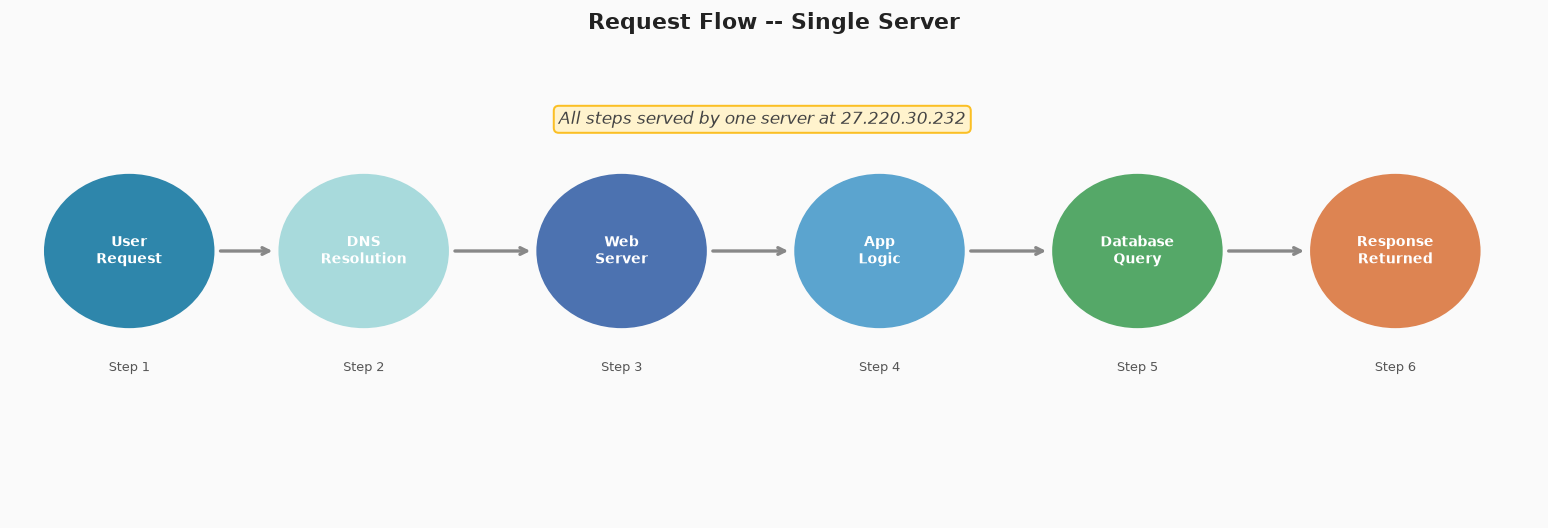

In [3]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.5)
ax.axis('off')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

steps = [
    (1.0, 'User\nRequest',      '#2E86AB'),
    (3.0, 'DNS\nResolution',    '#A8DADC'),
    (5.2, 'Web\nServer',        '#4C72B0'),
    (7.4, 'App\nLogic',         '#5BA4CF'),
    (9.6, 'Database\nQuery',    '#55A868'),
    (11.8,'Response\nReturned', '#DD8452'),
]

for i, (x, label, color) in enumerate(steps):
    circle = plt.Circle((x, 2.5), 0.72, color=color, zorder=3)
    ax.add_patch(circle)
    ax.text(x, 2.5, label, ha='center', va='center', fontsize=8.5,
            fontweight='bold', color='white', zorder=4)
    ax.text(x, 1.4, f'Step {i+1}', ha='center', va='center',
            fontsize=8, color='#555')
    if i < len(steps) - 1:
        ax.annotate('', xy=(steps[i+1][0] - 0.75, 2.5),
                    xytext=(x + 0.75, 2.5),
                    arrowprops=dict(arrowstyle='->', color='#888', lw=2))

ax.text(6.4, 3.7, 'All steps served by one server at 27.220.30.232',
        ha='center', fontsize=10, fontstyle='italic', color='#444',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD',
                  edgecolor='#FBBF24', lw=1.2))

ax.set_title('Request Flow -- Single Server', fontsize=13,
             fontweight='bold', color='#222')
plt.tight_layout()
plt.savefig('/tmp/sd_day1_flow.png', dpi=130, bbox_inches='tight')
plt.show()


## 3 — Where Does a Single Server Break?

There are three bottleneck dimensions. Each has a different *tell* and a different fix.

| Bottleneck | Symptom | First fix |
|---|---|---|
| **CPU** | Response time spikes under traffic | Vertical scale (bigger machine) -> horizontal split |
| **Database** | Query latency climbs, connections saturate | Read replicas, caching layer |
| **Network** | Bandwidth saturated, packet loss | CDN for static content, response compression |

The art is knowing *which one you hit first* — that determines your next architectural move.


/tmp/ipykernel_313809/1022300379.py:6: RuntimeWarning: invalid value encountered in power
  resp_cpu = np.where(traffic < 70, 50 + traffic * 0.5,                     50 + 35 + (traffic - 70) ** 2.2)
/tmp/ipykernel_313809/1022300379.py:18: RuntimeWarning: invalid value encountered in power
  db_latency = np.where(db_conns < 80, 20 + db_conns * 0.4,                        20 + 32 + (db_conns - 80) ** 2.5)
/tmp/ipykernel_313809/1022300379.py:29: RuntimeWarning: invalid value encountered in power
  pkt_loss  = np.where(bw_used < 90, bw_used * 0.01,                       0.9 + (bw_used - 90) ** 2.1)


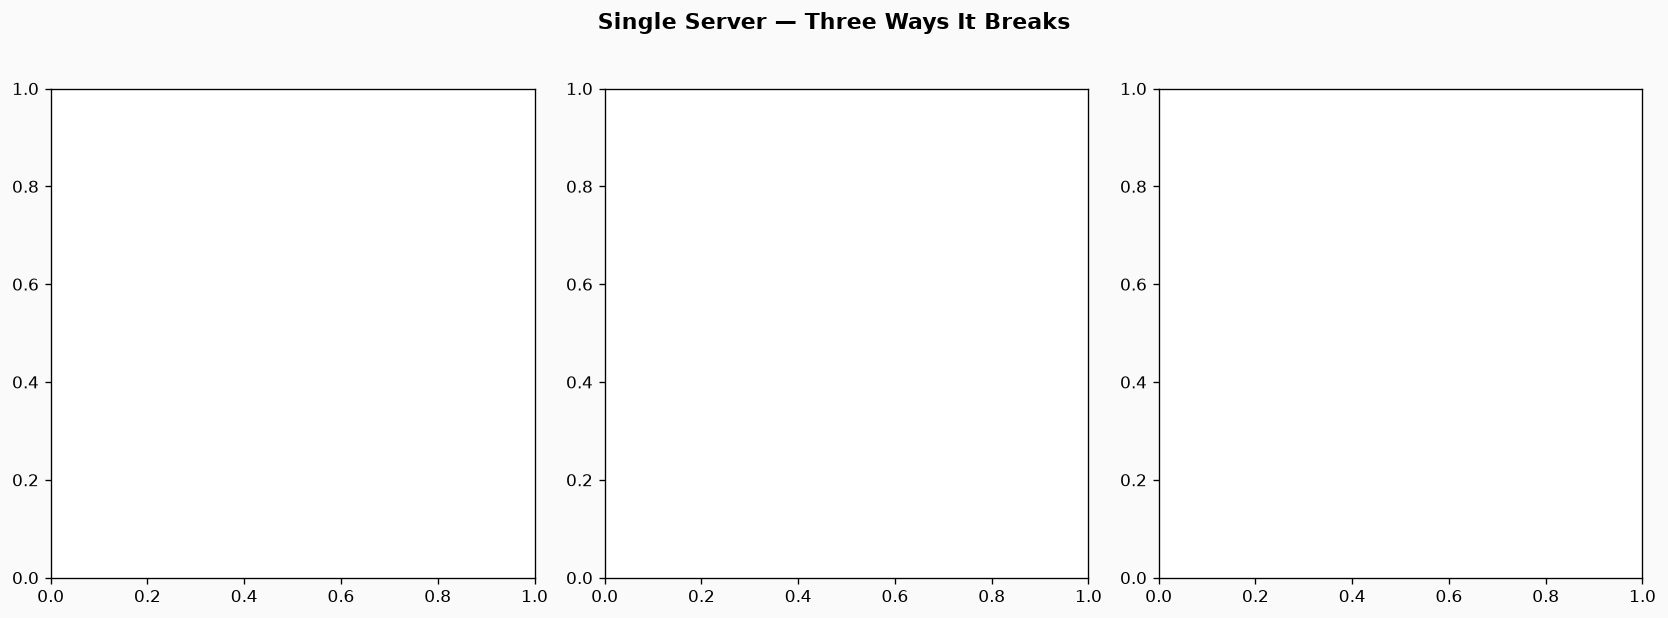

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA') 
traffic = np.linspace(0, 100, 300)  # % of max capacity\n
# ── CPU Bottleneck ──\nax = axes[0]
cpu_ok   = np.clip(traffic * 0.6, 0, 100)
resp_cpu = np.where(traffic < 70, 50 + traffic * 0.5,                     50 + 35 + (traffic - 70) ** 2.2)
ax.plot(traffic, cpu_ok,   color='#55A868', lw=2.5, label='CPU usage (%)')
ax.plot(traffic, resp_cpu / max(resp_cpu) * 100, color='#DD8452',         lw=2.5, linestyle='--', label='Response time (norm)')
ax.axvline(70, color='#C44E52', lw=1.8, linestyle=':', alpha=0.8)
ax.text(72, 85, 'CPU\nsaturates', fontsize=8, color='#C44E52')
ax.fill_between(traffic, 0, cpu_ok, alpha=0.08, color='#55A868')
ax.set_xlabel('Traffic load (%)', fontsize=9)
ax.set_ylabel('% of capacity / norm. latency', fontsize=8)
ax.set_title('Bottleneck 1: CPU', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.25); ax.set_ylim(0, 110) 
# ── DB Bottleneck ──\nax = axes[1]
db_conns  = np.clip(traffic * 1.4, 0, 100)
db_latency = np.where(db_conns < 80, 20 + db_conns * 0.4,                        20 + 32 + (db_conns - 80) ** 2.5)
ax.plot(traffic, db_conns,                       color='#4C72B0', lw=2.5, label='DB connections (%)')
ax.plot(traffic, db_latency / max(db_latency) * 100, color='#DD8452',         lw=2.5, linestyle='--', label='Query latency (norm)')
ax.axvline(57, color='#C44E52', lw=1.8, linestyle=':', alpha=0.8)
ax.text(59, 85, 'DB\nmaxxed', fontsize=8, color='#C44E52')
ax.fill_between(traffic, 0, db_conns, alpha=0.08, color='#4C72B0')
ax.set_xlabel('Traffic load (%)', fontsize=9)
ax.set_title('Bottleneck 2: Database', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.25); ax.set_ylim(0, 110) 
# ── Network Bottleneck ──\nax = axes[2]
bw_used   = np.clip(traffic * 1.1, 0, 100)
pkt_loss  = np.where(bw_used < 90, bw_used * 0.01,                       0.9 + (bw_used - 90) ** 2.1)
pkt_loss_norm = pkt_loss / max(pkt_loss) * 100
ax.plot(traffic, bw_used,       color='#9B59B6', lw=2.5, label='Bandwidth used (%)')
ax.plot(traffic, pkt_loss_norm, color='#DD8452', lw=2.5, linestyle='--', label='Packet loss (norm)')
ax.axvline(82, color='#C44E52', lw=1.8, linestyle=':', alpha=0.8)
ax.text(84, 85, 'Network\nfull', fontsize=8, color='#C44E52')
ax.fill_between(traffic, 0, bw_used, alpha=0.08, color='#9B59B6')
ax.set_xlabel('Traffic load (%)', fontsize=9)
ax.set_title('Bottleneck 3: Network', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.25); ax.set_ylim(0, 110) 
plt.suptitle('Single Server — Three Ways It Breaks', fontsize=13,              fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day1_bottlenecks.png', dpi=130, bbox_inches='tight')
plt.show() 

## 4 — Scaling Triggers: When Do You Add the Next Component?

You should not add complexity preemptively. Scale when the *system proves it needs to*.
Here are the concrete thresholds that justify each next move.


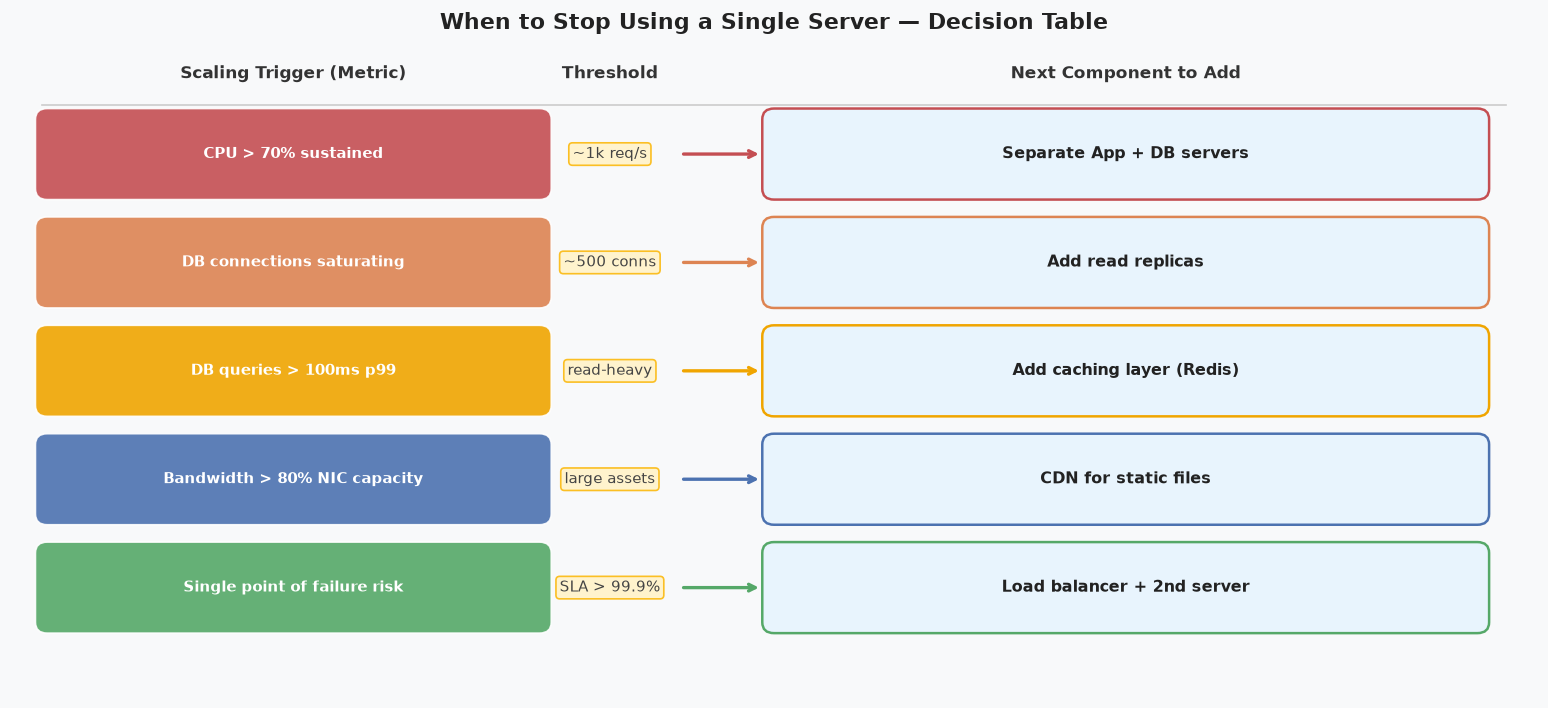

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13); ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

triggers = [
    # (y_pos, metric, threshold, next_component, color)
    (5.0, 'CPU > 70% sustained',           '~1k req/s',    'Separate App + DB servers',  '#C44E52'),
    (4.0, 'DB connections saturating',     '~500 conns',   'Add read replicas',           '#DD8452'),
    (3.0, 'DB queries > 100ms p99',        'read-heavy',   'Add caching layer (Redis)',    '#F0A500'),
    (2.0, 'Bandwidth > 80% NIC capacity',  'large assets', 'CDN for static files',        '#4C72B0'),
    (1.0, 'Single point of failure risk',  'SLA > 99.9%',  'Load balancer + 2nd server',  '#55A868'),
]

for y, metric, threshold, next_comp, color in triggers:
    # Metric box
    rect = FancyBboxPatch((0.3, y - 0.32), 4.2, 0.64,
                          boxstyle='round,pad=0.1', facecolor=color,
                          edgecolor='white', alpha=0.9)
    ax.add_patch(rect)
    ax.text(2.4, y, metric, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

    # Threshold tag
    ax.text(5.1, y, threshold, ha='center', va='center',
            fontsize=9, color='#444',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#FFF3CD', edgecolor='#FBBF24', lw=1))

    # Arrow
    ax.annotate('', xy=(6.4, y), xytext=(5.7, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))

    # Next component
    rect2 = FancyBboxPatch((6.5, y - 0.32), 6.0, 0.64,
                           boxstyle='round,pad=0.1', facecolor='#E8F4FD',
                           edgecolor=color, lw=1.5)
    ax.add_patch(rect2)
    ax.text(9.5, y, next_comp, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='#222')

# Column headers
ax.text(2.4, 5.7, 'Scaling Trigger (Metric)', ha='center', fontsize=10,
        fontweight='bold', color='#333')
ax.text(5.1, 5.7, 'Threshold', ha='center', fontsize=10,
        fontweight='bold', color='#333')
ax.text(9.5, 5.7, 'Next Component to Add', ha='center', fontsize=10,
        fontweight='bold', color='#333')

ax.axhline(5.45, xmin=0.02, xmax=0.98, color='#CCC', lw=1)
ax.set_title('When to Stop Using a Single Server — Decision Table',
             fontsize=13, fontweight='bold', color='#222', pad=10)
plt.tight_layout()
plt.savefig('/tmp/sd_day1_triggers.png', dpi=130, bbox_inches='tight')
plt.show()


## 5 — Single Server vs What Comes Next

Understanding *where you are* in the evolution is what makes every future Day valuable.


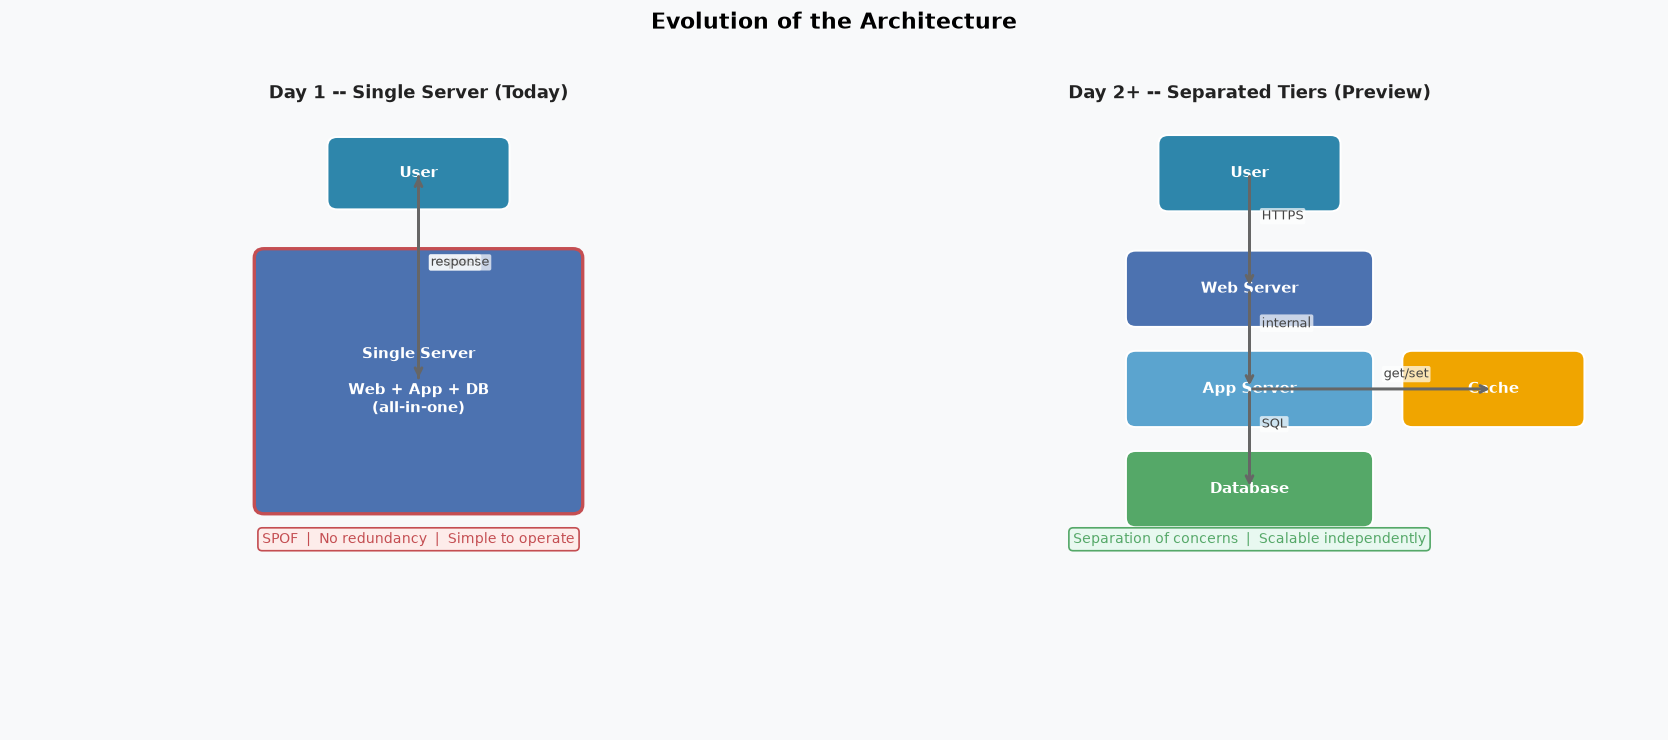

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F8F9FA')

def draw_server_diagram(ax, title, nodes, edges, highlight=None):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis('off')
    ax.set_facecolor('#F8F9FA')
    ax.set_title(title, fontsize=11, fontweight='bold', color='#222', pad=8)
    positions = {}
    for name, (x, y, w, h, label, color) in nodes.items():
        positions[name] = (x, y)
        rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                              boxstyle='round,pad=0.12',
                              lw=2 if highlight == name else 1.2,
                              facecolor=color,
                              edgecolor='#C44E52' if highlight == name else 'white')
        ax.add_patch(rect)
        ax.text(x, y, label, ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
    for (a, b, lbl) in edges:
        x1, y1 = positions[a]
        x2, y2 = positions[b]
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color='#666', lw=1.8))
        ax.text((x1+x2)/2 + 0.15, (y1+y2)/2 + 0.15, lbl,
                fontsize=7.5, color='#444',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                          alpha=0.7, lw=0))

single_server_label = 'Single Server\n\nWeb + App + DB\n(all-in-one)'

# Left: single server (today)
draw_server_diagram(
    axes[0], 'Day 1 -- Single Server (Today)',
    nodes={
        'user':   (5, 7.2, 2.0, 0.7, 'User',                 '#2E86AB'),
        'server': (5, 4.5, 3.8, 3.2, single_server_label,    '#4C72B0'),
    },
    edges=[('user', 'server', 'request'), ('server', 'user', 'response')],
    highlight='server'
)
axes[0].text(5, 2.4, 'SPOF  |  No redundancy  |  Simple to operate',
             ha='center', fontsize=8.5, color='#C44E52',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDECEA',
                       edgecolor='#C44E52', lw=1))

# Right: separated tiers (preview of Day 2+)
draw_server_diagram(
    axes[1], 'Day 2+ -- Separated Tiers (Preview)',
    nodes={
        'user':  (5, 7.2, 2.0, 0.75, 'User',       '#2E86AB'),
        'web':   (5, 5.7, 2.8, 0.75, 'Web Server', '#4C72B0'),
        'app':   (5, 4.4, 2.8, 0.75, 'App Server', '#5BA4CF'),
        'db':    (5, 3.1, 2.8, 0.75, 'Database',   '#55A868'),
        'cache': (8, 4.4, 2.0, 0.75, 'Cache',      '#F0A500'),
    },
    edges=[
        ('user', 'web',   'HTTPS'),
        ('web',  'app',   'internal'),
        ('app',  'db',    'SQL'),
        ('app',  'cache', 'get/set'),
    ]
)
axes[1].text(5, 2.4, 'Separation of concerns  |  Scalable independently',
             ha='center', fontsize=8.5, color='#55A868',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F8F0',
                       edgecolor='#55A868', lw=1))

plt.suptitle('Evolution of the Architecture', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day1_evolution.png', dpi=130, bbox_inches='tight')
plt.show()


## 6 — Key Takeaways

```
Day 1 Principles
================
1. Start simple.    One server forces clarity: what does the system actually do?
2. Find the bottleneck first.
                    CPU -> vertical scale or split tiers
                    DB   -> read replicas or cache
                    Net  -> CDN
3. Every large system was once a single server.
                    Twitter, GitHub, Airbnb — all started here.
4. Complexity has a cost.
                    Do not add load balancers, queues, or caches until a
                    MEASURED metric justifies it.
5. The scaling trigger IS the design decision.
                    The moment you ask "why do I need two servers?" you have
                    already done the most important system design thinking.
```

### What Day 2 will cover
**Separating the web tier from the data tier** — the first real scaling step:
- Dedicated web/app server
- Dedicated DB server
- What this buys you and what new problem it creates


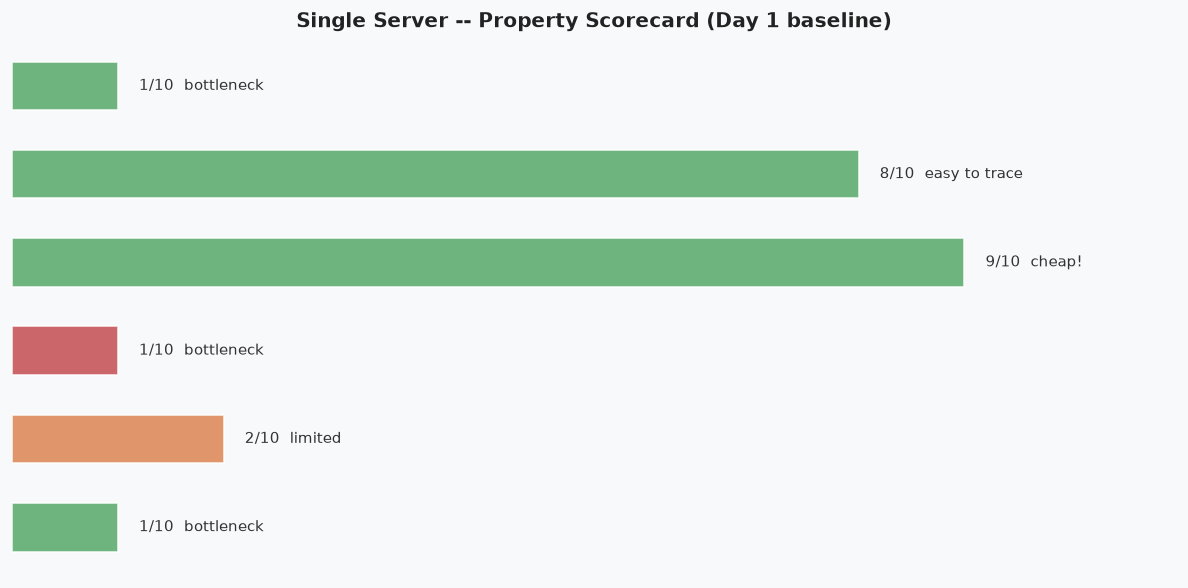

Day 1 complete.
Next: Day 2 -- Separating Web Tier and Data Tier


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

properties = [
    ('Complexity',    1, '#55A868'),
    ('Scalability',   2, '#DD8452'),
    ('Availability',  1, '#C44E52'),
    ('Cost',          9, '#55A868'),
    ('Observability', 8, '#55A868'),
    ('Ops overhead',  1, '#55A868'),
]

y_positions = np.arange(len(properties))
values  = [v for _, v, _ in properties]
colors  = [c for _, _, c in properties]
labels  = [l for l, _, _ in properties]

bars = ax.barh(y_positions, values, color=colors, alpha=0.85,
               edgecolor='white', height=0.55, left=0)
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlim(0, 11)
ax.set_xlabel('Score  (1 = low/poor,  10 = high/excellent)', fontsize=9)

title_text = 'Single Server -- Property Scorecard (Day 1 baseline)'
ax.set_title(title_text, fontsize=12, fontweight='bold', color='#222')

notes = {1: 'bottleneck', 2: 'limited', 9: 'cheap!', 8: 'easy to trace'}
for bar, val in zip(bars, values):
    note = notes.get(val, '')
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}/10  {note}', va='center', fontsize=9, color='#333')

ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('/tmp/sd_day1_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()

print("Day 1 complete.")
print("Next: Day 2 -- Separating Web Tier and Data Tier")
